In [ ]:
!pip install datasets

In [ ]:
import kagglehub
import os
from datasets import load_dataset
from transformers import ViTImageProcessor, ViTForImageClassification, TrainingArguments, Trainer
from PIL import Image
import numpy as np
import torch
import transformers
import inspect

In [ ]:
print("Transformers version:", transformers.__version__)
print("TrainingArguments module:", TrainingArguments.__module__)
print("TrainingArguments file:", inspect.getfile(TrainingArguments))
if transformers.__version__ < "4.11.0":
    raise ValueError("Please upgrade transformers to >= 4.11.0 using: pip install transformers==4.51.3")

Transformers version: 4.51.3
TrainingArguments module: transformers.training_args
TrainingArguments file: /usr/local/lib/python3.11/dist-packages/transformers/training_args.py


In [ ]:
path = kagglehub.dataset_download("salmaneunus/mechanical-tools-dataset")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/mechanical-tools-dataset


In [ ]:
print("Top-level directory contents:", os.listdir(path))

Top-level directory contents: ['hammer.csv.csv', 'train_data_V2', 'validation_data_V2', 'test_data', 'Mechanical Tools Image dataset', 'Mechanical_Tools_labelled.csv', 'Annotated.csv', 'train_data']


In [ ]:
def find_class_subfolders(base_path):
    for subdir in os.listdir(base_path):
        subdir_path = os.path.join(base_path, subdir)
        if os.path.isdir(subdir_path):
            subsubdir_contents = [d for d in os.listdir(subdir_path) if os.path.isdir(os.path.join(subdir_path, d))]
            if subsubdir_contents:
                print(f"Found potential class subfolders in {subdir}:", subsubdir_contents)
                return subdir_path, subsubdir_contents
    return None, None

In [ ]:
data_dir, class_labels = find_class_subfolders(path)
if data_dir and class_labels:
    print(f"Using data directory: {data_dir} with labels: {class_labels}")
else:
    print("No class subfolders found. Checking for metadata files...")
    metadata_files = [f for f in os.listdir(path) if f.endswith(('.csv', '.json', '.txt'))]
    if metadata_files:
        print("Found potential metadata files:", metadata_files)
        raise ValueError("Metadata file found. Please specify how to load labels from these files.")
    else:
        raise ValueError("No class subfolders or metadata files found. Please check dataset structure.")

Found potential class subfolders in train_data_V2: ['train_data_V2']
Using data directory: /kaggle/input/mechanical-tools-dataset/train_data_V2 with labels: ['train_data_V2']


In [ ]:
try:
    # Load the 'train' split first
    dataset = load_dataset("imagefolder", data_dir=data_dir, split="train")
    # Create train and test splits from the 'train' split
    dataset = dataset.train_test_split(test_size=0.2, seed=42)
except Exception as e:
    print("Error loading dataset:", e)
    raise

Resolving data files:   0%|          | 0/2400 [00:00<?, ?it/s]

In [ ]:
print("Dataset features:", dataset["train"].features)
print("First example:", dataset["train"][0])

Dataset features: {'image': Image(mode=None, decode=True, id=None), 'label': ClassLabel(names=['hammer', 'screwdriver', 'wrench'], id=None)}
First example: {'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=266x190 at 0x7E4F0FA5A4D0>, 'label': 0}


In [ ]:
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

In [ ]:
def preprocess(examples):
    images = [img.convert("RGB") if isinstance(img, Image.Image) else Image.open(img).convert("RGB") for img in examples["image"]]
    inputs = processor(images=images, return_tensors="pt", padding=True)
    examples["pixel_values"] = inputs["pixel_values"]
    return examples

In [ ]:
dataset = dataset.map(preprocess, batched=True)

Map:   0%|          | 0/1920 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/image_processing_utils.py:42: UserWarning: The following named arguments are not valid for `ViTImageProcessor.preprocess` and were ignored: 'padding'
  return self.preprocess(images, **kwargs)


Map:   0%|          | 0/480 [00:00<?, ? examples/s]

In [ ]:
labels = dataset["train"].features["label"].names
print("Extracted labels:", labels)

Extracted labels: ['hammer', 'screwdriver', 'wrench']


In [ ]:
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=len(labels),
    id2label={str(i): label for i, label in enumerate(labels)},
    label2id={label: str(i) for i, label in enumerate(labels)},
)

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir="./vit_tool_classifier",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    push_to_hub=False,
    logging_dir="./logs",
    logging_steps=10,
    report_to="none",  # Disable W&B and other external logging
)

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = (predictions == labels).mean()
    return {"accuracy": accuracy}

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.362900,0.366224,0.887500
2,0.246100,0.385646,0.868750
3,0.157200,0.365987,0.875000


TrainOutput(global_step=360, training_loss=0.30635862466361785, metrics={'train_runtime': 11671.0191, 'train_samples_per_second': 0.494, 'train_steps_per_second': 0.031, 'total_flos': 4.4635786070851584e+17, 'train_loss': 0.30635862466361785, 'epoch': 3.0})

In [ ]:
eval_results = trainer.evaluate()
print("Evaluation results:", eval_results)

Evaluation results: {'eval_loss': 0.3659874498844147, 'eval_accuracy': 0.875, 'eval_runtime': 321.3513, 'eval_samples_per_second': 1.494, 'eval_steps_per_second': 0.093, 'epoch': 3.0}


In [ ]:
trainer.save_model("./vit_tool_classifier_final")

In [ ]:
from transformers import ViTImageProcessor, ViTForImageClassification
from torch.utils.data import DataLoader
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

In [ ]:
model = ViTForImageClassification.from_pretrained("./vit_tool_classifier_final")
model.eval()

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [ ]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_curve, average_precision_score
from torch.utils.data import DataLoader
from itertools import cycle
import matplotlib.pyplot as plt

# Dataset & device
test_dataset = dataset["test"]

# Custom collate function
def custom_collate(batch):
    pixel_values = [item['pixel_values'] for item in batch]
    labels = [item['label'] for item in batch]
    pixel_values = [torch.tensor(pv) if not isinstance(pv, torch.Tensor) else pv for pv in pixel_values]
    pixel_values = torch.stack(pixel_values)
    labels = torch.tensor(labels)
    return {'pixel_values': pixel_values, 'label': labels}

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=custom_collate)

# Evaluation
model.eval()
predictions, true_labels, probs = [], [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)
        outputs = model(pixel_values)
        logits = outputs.logits
        preds = logits.argmax(-1).cpu().numpy()
        prob = torch.nn.functional.softmax(logits, dim=-1).cpu().numpy()

        predictions.extend(preds)
        true_labels.extend(labels.cpu().numpy())
        probs.extend(prob)

# Convert to numpy
predictions = np.array(predictions)
true_labels = np.array(true_labels)
probs = np.array(probs)

# Unique classes
report_labels = np.unique(true_labels)

# Accuracy
accuracy = accuracy_score(true_labels, predictions)
print(f"\n🔹 Accuracy: {accuracy:.4f}")

# Classification Report
print("\n📄 Classification Report:")
print(classification_report(true_labels, predictions, target_names=[str(label) for label in report_labels]))

# Confusion Matrix
print("\n🧮 Confusion Matrix:")
cm = confusion_matrix(true_labels, predictions, labels=report_labels)
print(cm)



🔹 Accuracy: 0.8750

📄 Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       148
           1       0.86      0.85      0.86       169
           2       0.90      0.91      0.91       163

    accuracy                           0.88       480
   macro avg       0.87      0.87      0.87       480
weighted avg       0.87      0.88      0.87       480


🧮 Confusion Matrix:
[[128  12   8]
 [ 17 144   8]
 [  4  11 148]]


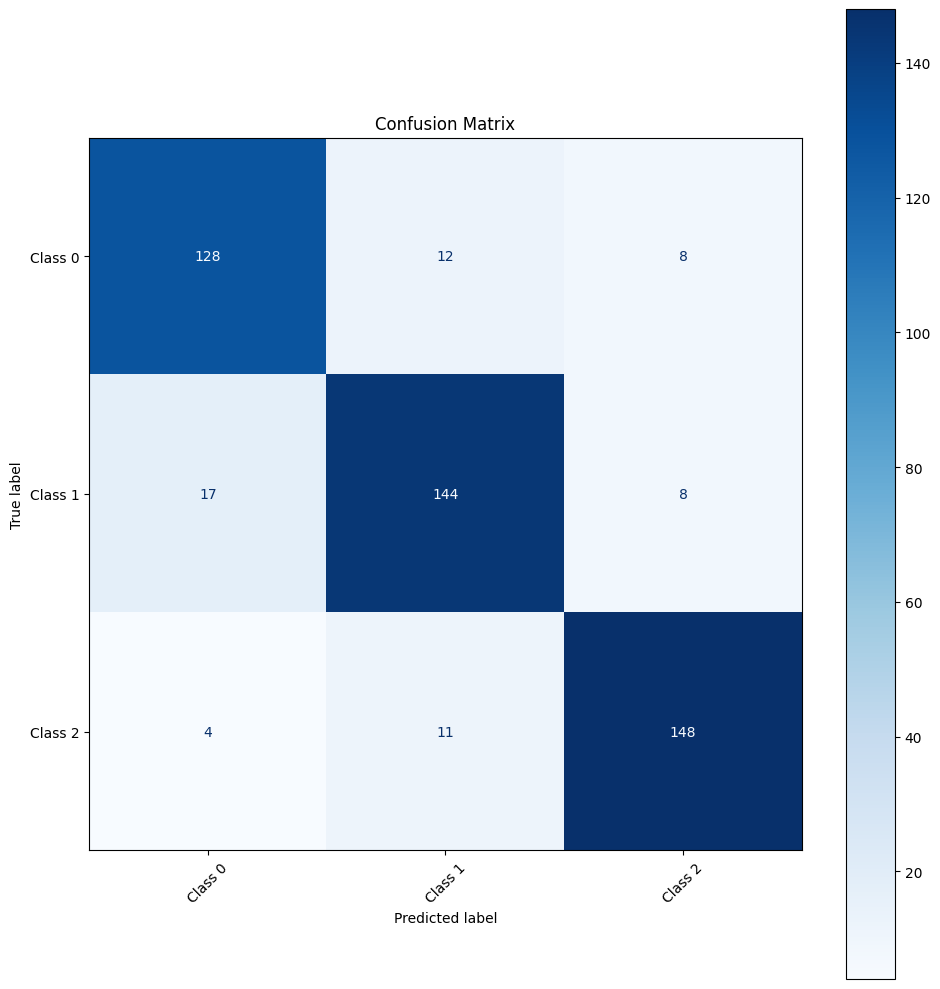

In [ ]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# === Prepare test loader ===
test_dataset = dataset["test"]

def custom_collate(batch):
    pixel_values = [item['pixel_values'] for item in batch]
    labels = [item['label'] for item in batch]
    pixel_values = [torch.tensor(pv) if not isinstance(pv, torch.Tensor) else pv for pv in pixel_values]
    return {
        'pixel_values': torch.stack(pixel_values),
        'label': torch.tensor(labels),
    }

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=custom_collate)

# === Run inference ===
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        x = batch["pixel_values"].to(device)
        y = batch["label"].to(device)
        out = model(x).logits
        preds = out.argmax(dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Convert to numpy arrays
preds = np.array(all_preds)
true = np.array(all_labels)

# === Confusion matrix as image ===
cmat = confusion_matrix(true, preds, labels=np.unique(true))
disp = ConfusionMatrixDisplay(cmat, display_labels=[f"Class {i}" for i in np.unique(true)])
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()


<ipython-input-51-20bf1917ede4>:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', 15)  # 'tab20' or 'nipy_spectral' gives good variety


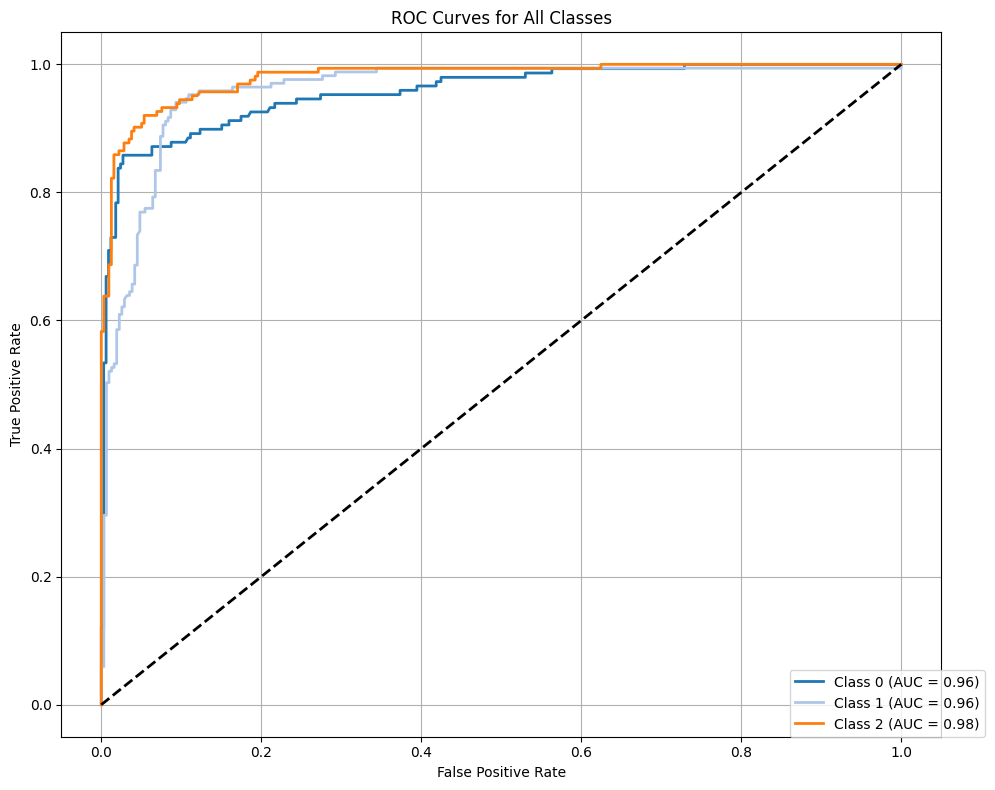

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Generate 15 unique colors using a colormap
cmap = cm.get_cmap('tab20', 15)  # 'tab20' or 'nipy_spectral' gives good variety

# ------------------------- ROC Curve -------------------------
plt.figure(figsize=(10, 8))

for i in range(len(report_labels)):
    fpr, tpr, _ = roc_curve(true_labels == report_labels[i], probs[:, report_labels[i]])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=cmap(i), lw=2, label=f'Class {report_labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Classes')
plt.legend(loc="lower right", bbox_to_anchor=(1.05, 0), borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()


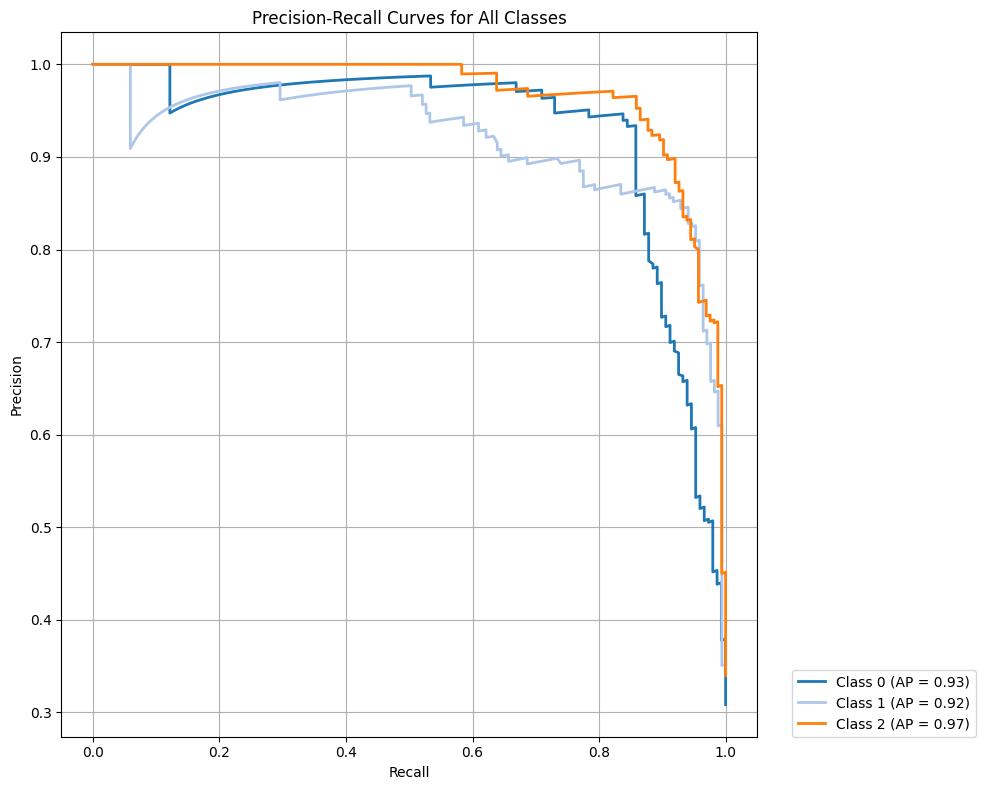

In [ ]:

# -------------------- Precision-Recall Curve --------------------
plt.figure(figsize=(10, 8))

for i in range(len(report_labels)):
    precision, recall, _ = precision_recall_curve(true_labels == report_labels[i], probs[:, report_labels[i]])
    avg_prec = average_precision_score(true_labels == report_labels[i], probs[:, report_labels[i]])
    plt.plot(recall, precision, color=cmap(i), lw=2, label=f'Class {report_labels[i]} (AP = {avg_prec:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for All Classes')
plt.legend(loc="lower left", bbox_to_anchor=(1.05, 0), borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()


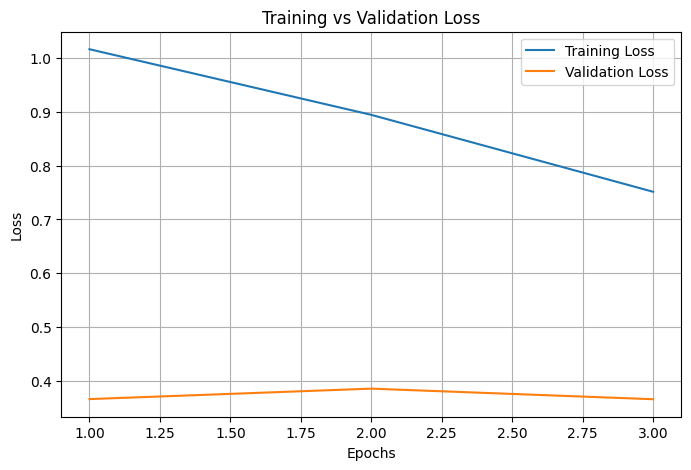

In [ ]:
# Step 6: Training vs Validation Loss Plot (Improved)
training_logs = trainer.state.log_history
# Get epochs where eval_loss is present
eval_epochs = [x['epoch'] for x in training_logs if 'eval_loss' in x]
# Get corresponding train_loss values for those epochs
# Modification: Get train loss for all epochs, then filter by eval_epochs
all_train_loss = [x['loss'] for x in training_logs if 'loss' in x]
train_loss_per_eval_epoch = [all_train_loss[int(epoch)-1] for epoch in eval_epochs]  # Use 'loss' for train loss
eval_loss = [x['eval_loss'] for x in training_logs if 'eval_loss' in x]

plt.figure(figsize=(8, 5))
# Plot using eval_epochs and train_loss_per_eval_epoch
plt.plot(eval_epochs, train_loss_per_eval_epoch, label='Training Loss')
plt.plot(eval_epochs, eval_loss, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.grid(True)
plt.show()

Labels: ['Class 0', 'Class 1', 'Class 2']
Classifier Counts: [128 144 148]
Misclassifier Counts: [21 23 16]


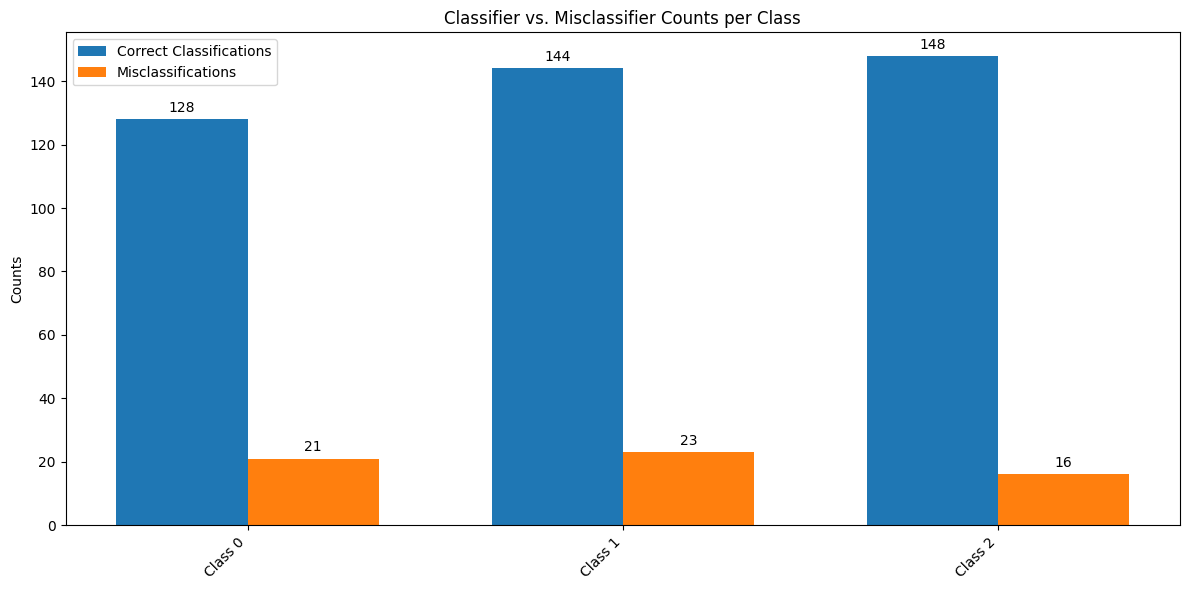

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_classifier_misclassifier_comparison(cm, labels):
    """
    Generates a bar graph comparing classifier and misclassifier counts per class.

    Args:
        cm: Confusion matrix (numpy array).
        labels: List of class labels.
    """
    # Debugging: Print confusion matrix and labels

    print("Labels:", labels)

    # Ensure cm is square and labels match
    if cm.shape[0] != cm.shape[1] or len(labels) != cm.shape[0]:
        raise ValueError(f"Confusion matrix must be square and match labels length. "
                         f"Got cm shape {cm.shape} and {len(labels)} labels.")

    classifier_counts = np.diag(cm)
    misclassifier_counts = np.sum(cm, axis=0) - classifier_counts

    # Debugging: Print counts
    print("Classifier Counts:", classifier_counts)
    print("Misclassifier Counts:", misclassifier_counts)

    x = np.arange(len(labels))  # the label locations
    width = 0.35  # the width of the bars

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot bars
    rects1 = ax.bar(x - width/2, classifier_counts, width, label='Correct Classifications')
    rects2 = ax.bar(x + width/2, misclassifier_counts, width, label='Misclassifications')

    # Add labels, title, and ticks
    ax.set_ylabel('Counts')
    ax.set_title('Classifier vs. Misclassifier Counts per Class')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.legend()

    # Add labels above each bar
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate('{}'.format(height),
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    fig.tight_layout()
    plt.show()

# Sample confusion matrix for 3 classes
cm = np.array([
 [128,  12,   8],
 [17, 144,   8],
 [4,  11, 148]    # Class 2: 7 correct, 0 misclassified as Class 0, 1 as Class 1
])

# Example usage with consistent labels
labels = ["Class 0", "Class 1", "Class 2"]
plot_classifier_misclassifier_comparison(cm, labels)